# 04 - Medium-Term Modeling

Review the one-month daily model, validation metrics, saved model, and final forecasts.

In [6]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

metrics_path = ROOT / "outputs" / "group5" / "metrics" / "validation_metrics.csv"
valid_path = ROOT / "outputs" / "group5" / "metrics" / "validation_predictions_daily.csv"
forecast_path = ROOT / "outputs" / "group5" / "predictions" / "group_5_daily_predict.csv"
model_path = ROOT / "models" / "medium_term" / "group5_daily_gradient_boosting.joblib"

print("Run the pipeline first if these files are missing:")
print("EI-climat/bin/python scripts/group5_run_pipeline.py")

Run the pipeline first if these files are missing:
EI-climat/bin/python scripts/group5_run_pipeline.py


In [7]:
metrics = pd.read_csv(metrics_path)
daily_metrics = metrics[metrics["frequency"] == "daily"].sort_values(["acorn", "rmse"])
daily_metrics

,frequency,model,acorn,rmse,n
37,daily,gradient_boosting,ACORN-E,0.422722,31
33,daily,ridge,ACORN-E,0.422982,31
21,daily,previous_day,ACORN-E,0.488096,31
25,daily,previous_week,ACORN-E,0.576484,31
29,daily,seasonal_mean,ACORN-E,1.857962,31
38,daily,gradient_boosting,ACORN-F,0.409899,31
34,daily,ridge,ACORN-F,0.428852,31
26,daily,previous_week,ACORN-F,0.494960,31
22,daily,previous_day,ACORN-F,0.554479,31
30,daily,seasonal_mean,ACORN-F,1.601140,31


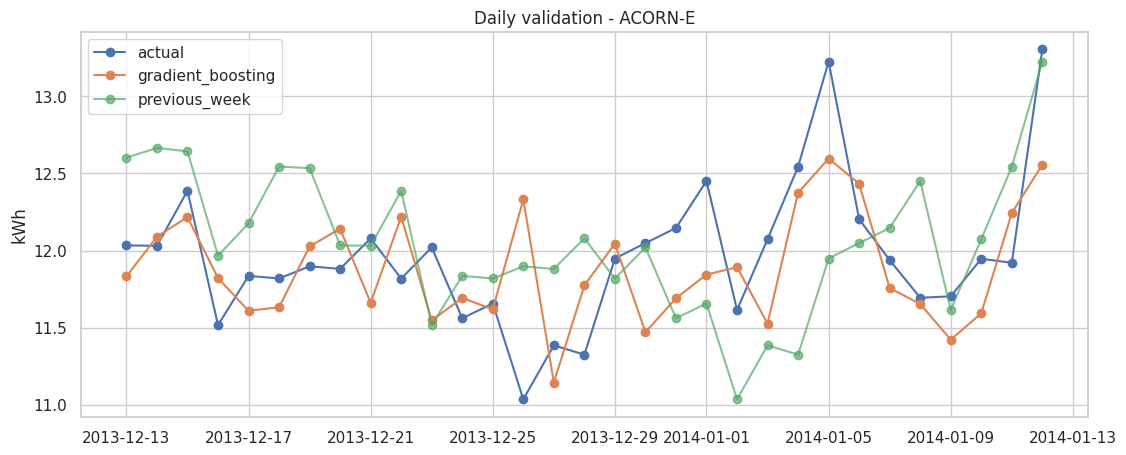

In [8]:
valid = pd.read_csv(valid_path, parse_dates=["timestamp"])
acorn = "ACORN-E"
plot_df = valid[valid["Acorn"] == acorn].copy()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(plot_df["timestamp"], plot_df["actual"], marker="o", label="actual")
ax.plot(plot_df["timestamp"], plot_df["gradient_boosting"], marker="o", label="gradient_boosting")
ax.plot(plot_df["timestamp"], plot_df["previous_week"], marker="o", label="previous_week", alpha=0.7)
ax.set_title(f"Daily validation - {acorn}")
ax.set_ylabel("kWh")
ax.legend()
plt.show()

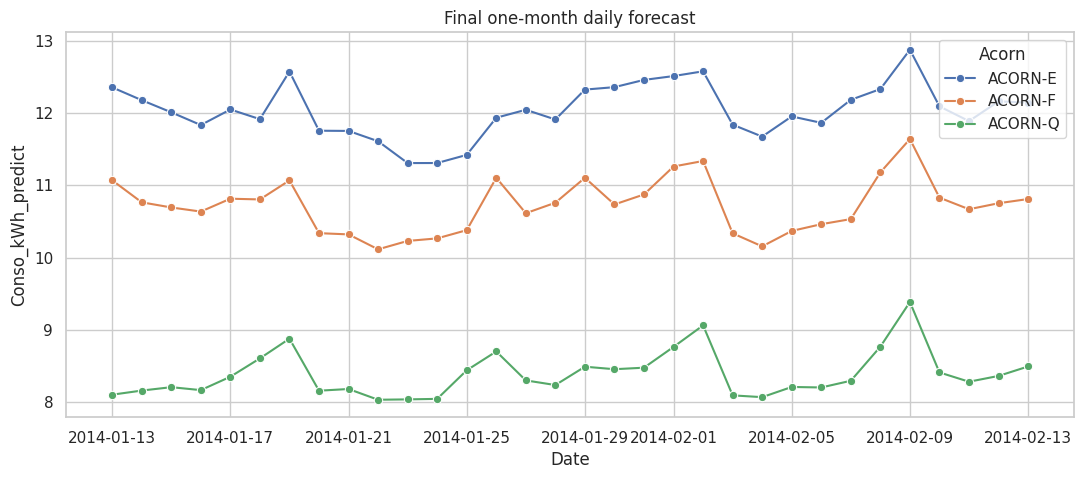

,Acorn,Date,Conso_kWh_predict
0,ACORN-E,2014-01-13,12.354000
1,ACORN-E,2014-01-14,12.177100
2,ACORN-E,2014-01-15,12.008986
3,ACORN-E,2014-01-16,11.833144
4,ACORN-E,2014-01-17,12.048121


In [9]:
forecast = pd.read_csv(forecast_path, parse_dates=["Date"])
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=forecast, x="Date", y="Conso_kWh_predict", hue="Acorn", marker="o", ax=ax)
ax.set_title("Final one-month daily forecast")
plt.show()

forecast.head()

In [10]:
print("Saved medium-term model:", model_path)
print("Exists:", model_path.exists())

Saved medium-term model: /home/baunilha/Repositories/ei-climat/models/medium_term/group5_daily_gradient_boosting.joblib
Exists: True
